In [8]:
import json
import numpy as np
import pyvisa
import time
import hid # pip install hidapi
import skrf as rf
import matplotlib.pyplot as plt
import serial.tools.list_ports
from windfreak import SynthHD
from RsInstrument import RsInstrument, BinFloatFormat
from datetime import datetime

rm = pyvisa.ResourceManager()
instruments = rm.list_resources()
spa = None
for instrument in instruments:
    if '7405' in instrument:
        spa = rm.open_resource(instrument) 
        break

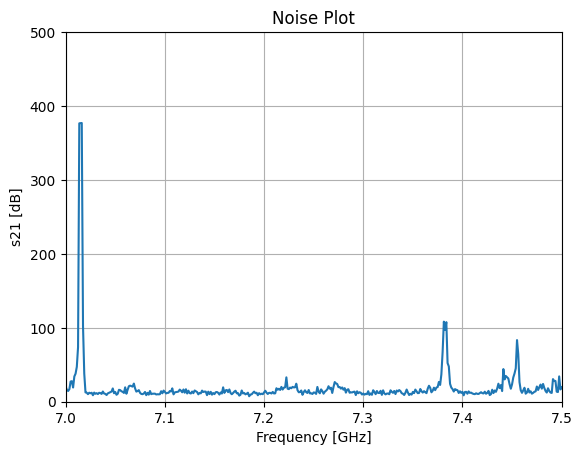

In [9]:
spa_trace = {}
spa_trace['idn'] = spa.query('*IDN?').strip()
spa_trace['spa_start_frequency']    = float(spa.query(':SENS1:FREQ:START?'))
spa_trace['spa_stop_frequency']     = float(spa.query(':SENS1:FREQ:STOP?'))
spa_trace['spa_number_of_points'] = int(spa.query(':SENS1:SWEep:POINts?'))
spa_trace['rbw']      = float(spa.query(':SENS:BAND?'))
spa_trace['vbw'] = float(spa.query(':SENS:BAND:VID?'))
spa_trace['unit'] = spa.query(":UNIT:POW?").strip()
frequencies = np.linspace(spa_trace['spa_start_frequency'],spa_trace['spa_stop_frequency'],spa_trace['spa_number_of_points'])
fghz = frequencies/1e9

now = datetime.now().astimezone()
spa_trace['timestamp'] = int(now.timestamp())
spa_trace['date'] = now.strftime("%d-%m-%Y")
spa_trace['time'] = now.strftime("%H:%M:%S")
spa_trace['timezone'] = now.tzname()
spa.write("INIT:IMM")
spa.query("*OPC?") 
trace = np.array(spa.query_binary_values("TRAC? TRACE1", datatype="f", is_big_endian=True))
spa_trace['power'] = trace.tolist()
spa_trace['fghz'] = fghz.tolist()
spa.write(":SYST:LOCAL")

plt.plot(fghz, trace/1e-9)
plt.xlim(fghz[0], fghz[-1])
plt.ylim(0,500)
plt.title('Noise Plot')
plt.grid()
plt.xlabel('Frequency [GHz]')
plt.ylabel('s21 [dB]')
plot_file_name = f"{spa_trace['timestamp']}-spa-plot.png"
plt.savefig(plot_file_name, dpi=300, bbox_inches='tight')

json_file_name = f"{spa_trace['timestamp']}-spa-trace.json"

with open(json_file_name, "w", encoding="utf-8") as f:
    json.dump(spa_trace, f, indent=4)

